In [2]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")
print(f"GPU disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Dispositivo: cuda
GPU disponible: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [4]:
# Rutas del dataset
BASE_PATH = r'C:\Users\WinterOS\deteccion-lesiones-rayosx\data\raw\MURA-v1.1'

# Cargar CSVs
train_df = pd.read_csv(f'{BASE_PATH}/train_labeled_studies.csv', 
                        header=None, names=['path', 'label'])
valid_df = pd.read_csv(f'{BASE_PATH}/valid_labeled_studies.csv', 
                        header=None, names=['path', 'label'])

# Limpiar paths
train_df['path'] = train_df['path'].str.replace('MURA-v1.1/', '', regex=False)
valid_df['path'] = valid_df['path'].str.replace('MURA-v1.1/', '', regex=False)

print("Train:", len(train_df), "estudios")
print("Valid:", len(valid_df), "estudios")
print(train_df.head())

Train: 13457 estudios
Valid: 1199 estudios
                                              path  label
0  train/XR_SHOULDER/patient00001/study1_positive/      1
1  train/XR_SHOULDER/patient00002/study1_positive/      1
2  train/XR_SHOULDER/patient00003/study1_positive/      1
3  train/XR_SHOULDER/patient00004/study1_positive/      1
4  train/XR_SHOULDER/patient00005/study1_positive/      1


In [5]:
class MURADataset(Dataset):
    def __init__(self, df, base_path, transform=None):
        self.data = []
        self.transform = transform
        
        for _, row in df.iterrows():
            folder = os.path.join(base_path, row['path'])
            if os.path.exists(folder):
                for img_file in os.listdir(folder):
                    if img_file.endswith('.png'):
                        self.data.append({
                            'path': os.path.join(folder, img_file),
                            'label': row['label']
                        })
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        img = Image.open(item['path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, item['label']

print("Clase MURADataset definida ")

Clase MURADataset definida 


In [6]:
# Transformaciones
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

valid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

# Muestra reducida
train_sample = train_df.sample(n=5000, random_state=42).reset_index(drop=True)
valid_sample = valid_df.sample(n=800, random_state=42).reset_index(drop=True)

print("Cargando dataset reducido...")
train_dataset = MURADataset(train_sample, BASE_PATH, transform=train_transform)
print(f"Train: {len(train_dataset)} imágenes")

valid_dataset = MURADataset(valid_sample, BASE_PATH, transform=valid_transform)
print(f"Valid: {len(valid_dataset)} imágenes")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

print("DataLoaders listos ✅")

Cargando dataset reducido...
Train: 13667 imágenes
Valid: 2161 imágenes
DataLoaders listos ✅


In [7]:
import torchvision.models as models

# Cargar EfficientNetB0 preentrenado
model = models.efficientnet_b0(weights='IMAGENET1K_V1')

# Congelar capas base
for param in model.parameters():
    param.requires_grad = False

# Modificar la última capa para clasificación binaria
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(model.classifier[1].in_features, 1)
)

# Mover modelo a GPU
model = model.to(device)

print("Modelo EfficientNetB0 cargado ✅")
print(f"Parámetros entrenables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Modelo EfficientNetB0 cargado ✅
Parámetros entrenables: 1,281


In [8]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calcular class weights para el desbalance
labels = train_df['label'].values
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class weights: {class_weights}")

# Función de pérdida con class weight
criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights[1])

# Optimizador
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.001)

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5
)

print("Optimizador y criterion definidos ✅")

Class weights: tensor([0.8126, 1.2997], device='cuda:0')
Optimizador y criterion definidos ✅


In [9]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.float().to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / len(loader), correct / total

def valid_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.float().to(device)
            
            outputs = model(imgs).squeeze(1)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    return total_loss / len(loader), correct / total

print("Funciones de entrenamiento definidas ✅")

Funciones de entrenamiento definidas ✅


In [10]:
NUM_EPOCHS = 10
best_valid_loss = float('inf')
history = {'train_loss': [], 'valid_loss': [], 'train_acc': [], 'valid_acc': []}

print("Iniciando entrenamiento...")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    valid_loss, valid_acc = valid_epoch(model, valid_loader, criterion, device)
    
    scheduler.step(valid_loss)
    
    history['train_loss'].append(train_loss)
    history['valid_loss'].append(valid_loss)
    history['train_acc'].append(train_acc)
    history['valid_acc'].append(valid_acc)
    
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), r'C:\Users\WinterOS\deteccion-lesiones-rayosx\models\best_model.pth')
        print(f"Época {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f} ⭐ Mejor modelo guardado")
    else:
        print(f"Época {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")

print("=" * 60)
print("¡Entrenamiento completado! ✅")

Iniciando entrenamiento...


KeyboardInterrupt: 

C:\Users\WinterOS\AppData\Local\Temp\ipykernel_15616\2115285242.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(r'C:\Users\WinterOS\dete

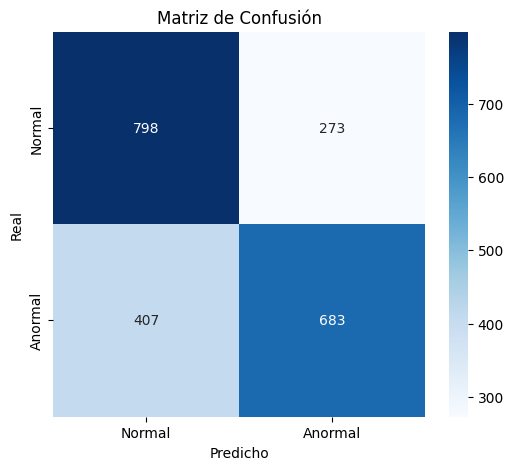

              precision    recall  f1-score   support

      Normal       0.66      0.75      0.70      1071
     Anormal       0.71      0.63      0.67      1090

    accuracy                           0.69      2161
   macro avg       0.69      0.69      0.68      2161
weighted avg       0.69      0.69      0.68      2161



In [11]:
model.load_state_dict(torch.load(r'C:\Users\WinterOS\deteccion-lesiones-rayosx\models\best_model.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in valid_loader:
        imgs = imgs.to(device)
        outputs = model(imgs).squeeze(1)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anormal'],
            yticklabels=['Normal', 'Anormal'])
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

print(classification_report(all_labels, all_preds, target_names=['Normal', 'Anormal']))

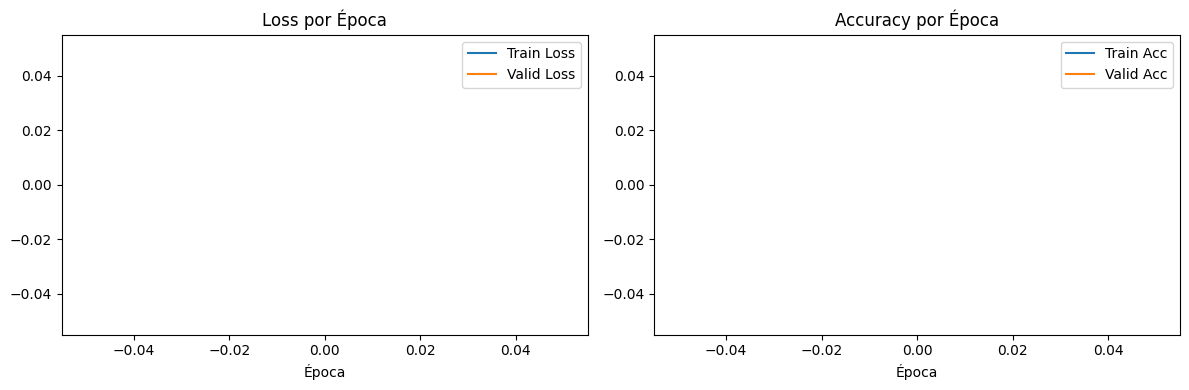

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['valid_loss'], label='Valid Loss')
axes[0].set_title('Loss por Época')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['valid_acc'], label='Valid Acc')
axes[1].set_title('Accuracy por Época')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.tight_layout()
plt.show()

C:\Users\WinterOS\AppData\Local\Temp\ipykernel_15616\2302723064.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(r'C:\Users\WinterOS\dete

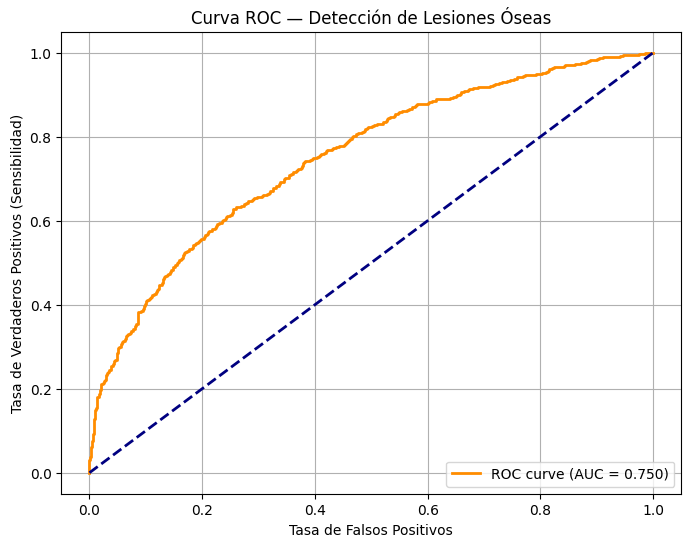

AUC-ROC: 0.7504


In [13]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Obtener probabilidades
model.load_state_dict(torch.load(r'C:\Users\WinterOS\deteccion-lesiones-rayosx\models\best_model.pth'))
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for imgs, labels in valid_loader:
        imgs = imgs.to(device)
        outputs = model(imgs).squeeze(1)
        probs = torch.sigmoid(outputs).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

# ROC-AUC
auc = roc_auc_score(all_labels, all_probs)
fpr, tpr, _ = roc_curve(all_labels, all_probs)

# Gráfica
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC — Detección de Lesiones Óseas')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"AUC-ROC: {auc:.4f}")